## LAB7: PHÂN ĐOẠN ẢNH (IMAGE SEGMENTATION)

In [ ]:
import cv2 as cv
import matplotlib.pyplot as NguyenHuynhAnhTu
!pip install opencv-python


#1. Thresholding để phân đoạn ảnh

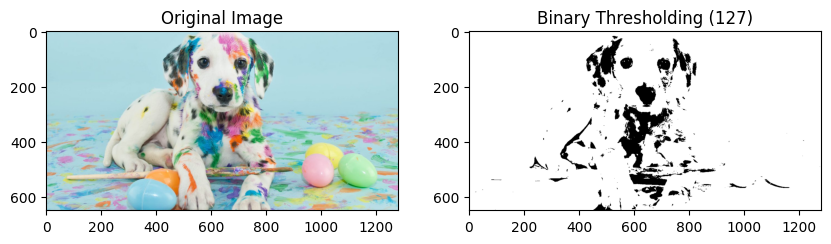

In [ ]:
import numpy as np

# Đọc ảnh và chuyển sang ảnh xám
image = cv.imread('hinh2.png')
gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

# Áp dụng Simple Thresholding (ngưỡng 127)
ret, thresh1 = cv.threshold(gray, 127, 255, cv.THRESH_BINARY)

# Hiển thị kết quả
NguyenHuynhAnhTu.figure(figsize=(10, 5))
NguyenHuynhAnhTu.subplot(1, 2, 1)
NguyenHuynhAnhTu.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
NguyenHuynhAnhTu.title('Original Image')

NguyenHuynhAnhTu.subplot(1, 2, 2)
NguyenHuynhAnhTu.imshow(thresh1, 'gray')
NguyenHuynhAnhTu.title('Binary Thresholding (127)')
NguyenHuynhAnhTu.show()

#2. Otsu algorithm để phân đoạn ảnh vân tay

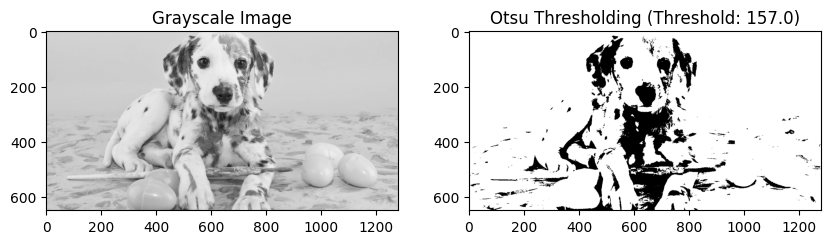

In [ ]:
# Áp dụng Otsu's Thresholding
ret_otsu, thresh_otsu = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# Hiển thị kết quả
NguyenHuynhAnhTu.figure(figsize=(10, 5))
NguyenHuynhAnhTu.subplot(1, 2, 1)
NguyenHuynhAnhTu.imshow(gray, 'gray')
NguyenHuynhAnhTu.title('Grayscale Image')

NguyenHuynhAnhTu.subplot(1, 2, 2)
NguyenHuynhAnhTu.imshow(thresh_otsu, 'gray')
NguyenHuynhAnhTu.title(f'Otsu Thresholding (Threshold: {ret_otsu})')
NguyenHuynhAnhTu.show()

#3. Clustering techniques trong phân đoạn ảnh, K-mean clustering

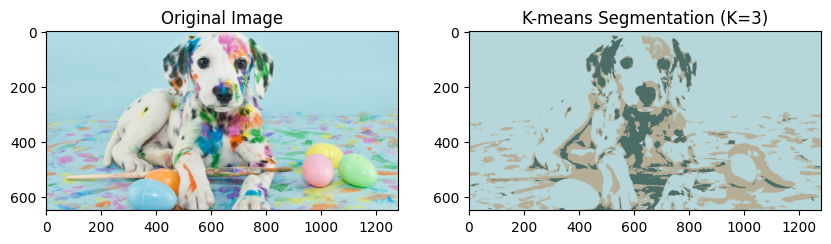

In [ ]:
# Chuẩn bị dữ liệu: chuyển ảnh về mảng 2D các điểm ảnh (pixel)
pixel_values = image.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# Định nghĩa tiêu chí dừng (criteria) và số cụm K
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)
k = 3  # Số lượng vùng muốn phân đoạn

# Áp dụng thuật toán K-means
_, labels, centers = cv.kmeans(pixel_values, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

# Chuyển đổi dữ liệu về dạng ảnh ban đầu
centers = np.uint8(centers)
segmented_data = centers[labels.flatten()]
segmented_image = segmented_data.reshape((image.shape))

# Hiển thị kết quả
NguyenHuynhAnhTu.figure(figsize=(10, 5))
NguyenHuynhAnhTu.subplot(1, 2, 1)
NguyenHuynhAnhTu.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
NguyenHuynhAnhTu.title('Original Image')

NguyenHuynhAnhTu.subplot(1, 2, 2)
NguyenHuynhAnhTu.imshow(cv.cvtColor(segmented_image, cv.COLOR_BGR2RGB))
NguyenHuynhAnhTu.title(f'K-means Segmentation (K={k})')
NguyenHuynhAnhTu.show()

#4. Sử dụng thuật toán Region growing

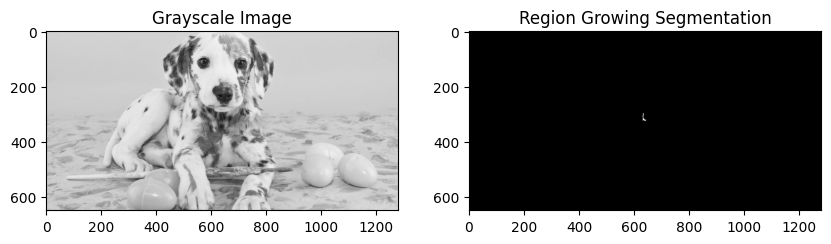

In [ ]:
def region_growing(img, seed, thresh=10):
    height, width = img.shape
    segmented = np.zeros_like(img)
    seed_list = [seed]
    segmented[seed] = 255

    while len(seed_list) > 0:
        current_pt = seed_list.pop(0)
        for i in range(-1, 2):
            for j in range(-1, 2):
                x, y = current_pt[0] + i, current_pt[1] + j
                if 0 <= x < height and 0 <= y < width:
                    if segmented[x, y] == 0 and abs(int(img[x, y]) - int(img[seed])) < thresh:
                        segmented[x, y] = 255
                        seed_list.append((x, y))
    return segmented

# Chọn tọa độ hạt giống (ví dụ vùng giữa ảnh)
seed_pt = (gray.shape[0] // 2, gray.shape[1] // 2)
reg_growing_res = region_growing(gray, seed_pt)

# Hiển thị kết quả
NguyenHuynhAnhTu.figure(figsize=(10, 5))
NguyenHuynhAnhTu.subplot(1, 2, 1)
NguyenHuynhAnhTu.imshow(gray, 'gray')
NguyenHuynhAnhTu.title('Grayscale Image')

NguyenHuynhAnhTu.subplot(1, 2, 2)
NguyenHuynhAnhTu.imshow(reg_growing_res, 'gray')
NguyenHuynhAnhTu.title('Region Growing Segmentation')
NguyenHuynhAnhTu.show()

#5. Sử dụng thuật toán Split and merge để phân đoạn ảnh

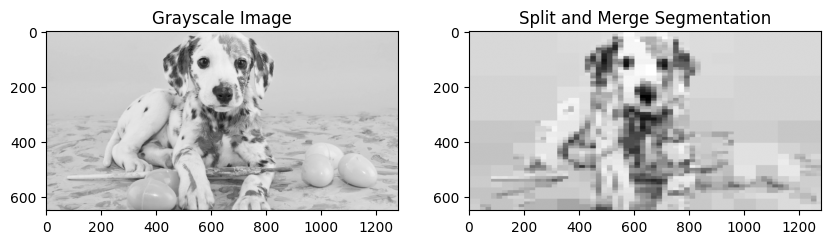

In [ ]:
def split_and_merge(img, min_size=8, threshold=20):
    height, width = img.shape
    segmented = np.zeros_like(img)

    def get_stats(region):
        return np.mean(region), np.std(region)

    def recursive_split(r, c, h, w):
        region = img[r:r+h, c:c+w]
        mean, std = get_stats(region)

        if std <= threshold or h <= min_size or w <= min_size:
            segmented[r:r+h, c:c+w] = mean
            return

        h2, w2 = h // 2, w // 2
        recursive_split(r, c, h2, w2)
        recursive_split(r, c + w2, h2, w - w2)
        recursive_split(r + h2, c, h - h2, w2)
        recursive_split(r + h2, c + w2, h - h2, w - w2)

    recursive_split(0, 0, height, width)
    return segmented.astype(np.uint8)

# Áp dụng thuật toán
split_merge_res = split_and_merge(gray, min_size=16, threshold=15)

# Hiển thị kết quả
NguyenHuynhAnhTu.figure(figsize=(10, 5))
NguyenHuynhAnhTu.subplot(1, 2, 1)
NguyenHuynhAnhTu.imshow(gray, 'gray')
NguyenHuynhAnhTu.title('Grayscale Image')

NguyenHuynhAnhTu.subplot(1, 2, 2)
NguyenHuynhAnhTu.imshow(split_merge_res, 'gray')
NguyenHuynhAnhTu.title('Split and Merge Segmentation')
NguyenHuynhAnhTu.show()

#6. Phân đoạn ảnh với Edge-based sigmentation

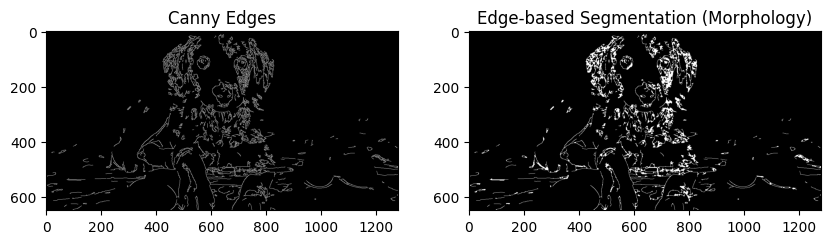

In [ ]:
# Sử dụng Canny để tìm biên
edges = cv.Canny(gray, 100, 200)

# Sử dụng phép đóng (Closing) để nối các cạnh dính liền
kernel = np.ones((3, 3), np.uint8)
closed_edges = cv.morphologyEx(edges, cv.MORPH_CLOSE, kernel)

# Hiển thị kết quả
NguyenHuynhAnhTu.figure(figsize=(10, 5))
NguyenHuynhAnhTu.subplot(1, 2, 1)
NguyenHuynhAnhTu.imshow(edges, 'gray')
NguyenHuynhAnhTu.title('Canny Edges')

NguyenHuynhAnhTu.subplot(1, 2, 2)
NguyenHuynhAnhTu.imshow(closed_edges, 'gray')
NguyenHuynhAnhTu.title('Edge-based Segmentation (Morphology)')
NguyenHuynhAnhTu.show()

##Lab 08: NHẬN DIỆN ĐỐI TƯỢNG TRONG VIDEO (VIDEO DETECTION)

In [23]:
!pip install imageai
from imageai.Detection import VideoObjectDetection
import os

execution_path = os.getcwd()
detector = VideoObjectDetection()
detector.setModelTypeAsRetinaNet()
detector.setModelPath( os.path.join(execution_path , "retinanet_resnet50_fpn_coco-eeacb38b.pth"))
detector.loadModel()
video_path = detector.detectObjectsFromVideo(input_file_path=os.path.join(execution_path, "video_predetect.mp4"),
                                output_file_path=os.path.join(execution_path, "video_detected")
                                , frames_per_second=5, log_progress=True)
print(video_path)


Processing Frame :  1
Processing Frame :  2
Processing Frame :  3
Processing Frame :  4
Processing Frame :  5
Processing Frame :  6
Processing Frame :  7
Processing Frame :  8
Processing Frame :  9
Processing Frame :  10
Processing Frame :  11
Processing Frame :  12
Processing Frame :  13
Processing Frame :  14
Processing Frame :  15
Processing Frame :  16
Processing Frame :  17
Processing Frame :  18
Processing Frame :  19
Processing Frame :  20
Processing Frame :  21
Processing Frame :  22
Processing Frame :  23
Processing Frame :  24
Processing Frame :  25
Processing Frame :  26
Processing Frame :  27
Processing Frame :  28
Processing Frame :  29
Processing Frame :  30
Processing Frame :  31
Processing Frame :  32
Processing Frame :  33
Processing Frame :  34
Processing Frame :  35
Processing Frame :  36
Processing Frame :  37
Processing Frame :  38
Processing Frame :  39
Processing Frame :  40
Processing Frame :  41
Processing Frame :  42
Processing Frame :  43
Processing Frame :  

In [22]:
!wget -O retinanet_resnet50_fpn_coco-eeacb38b.pth \
https://download.pytorch.org/models/retinanet_resnet50_fpn_coco-eeacb38b.pth

--2026-03-27 09:44:15--  https://download.pytorch.org/models/retinanet_resnet50_fpn_coco-eeacb38b.pth
Resolving download.pytorch.org (download.pytorch.org)... 99.84.215.76, 99.84.215.59, 99.84.215.89, ...
Connecting to download.pytorch.org (download.pytorch.org)|99.84.215.76|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 136595076 (130M) [binary/octet-stream]
Saving to: ‘retinanet_resnet50_fpn_coco-eeacb38b.pth’

retinanet_resnet50_ 100%[===================>] 130.27M   317MB/s    in 0.4s    

2026-03-27 09:44:16 (317 MB/s) - ‘retinanet_resnet50_fpn_coco-eeacb38b.pth’ saved [136595076/136595076]

